# Exploratory Data Analysis

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [11]:
# Data Cleaning:

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


## Filter for UK Data Analyst Roles

In [14]:
country = 'United Kingdom'
role = 'Data Analyst'

In [15]:
df_DA_UK = df[(df['job_country'] == country) & (df['job_title_short'] == role)].copy()

In [19]:
df_plot = df_DA_UK['job_location'].value_counts().head(10).to_frame()
df_plot.head()

,count
job_location,
United Kingdom,1989
Anywhere,959
"England, UK",610
"Manchester, UK",595
"Birmingham, UK",440


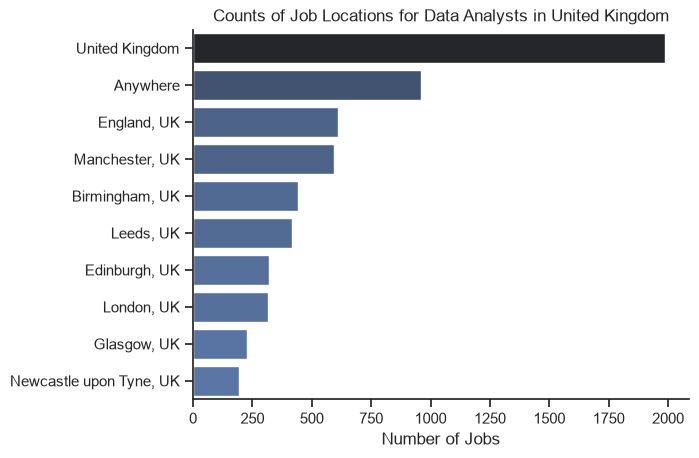

In [30]:
sns.set_theme(style="ticks")

sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title(f"Counts of Job Locations for {role}s in {country}")
plt.xlabel("Number of Jobs")
plt.ylabel(None)
plt.show()

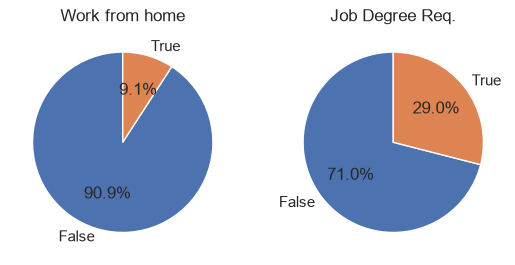

In [32]:
fix, ax = plt.subplots(1, 2)
# fix, ax = plt.subplots(1, 3)

plot_columns = {
    'job_work_from_home': "Work from home",
    'job_no_degree_mention': "Job Degree Req.",
    # 'job_health_insurance': "Health Insurance Offered"
}

for i, (column, title) in enumerate(plot_columns.items()):
    ax[i].pie(df_DA_UK[column].value_counts(), startangle=90, autopct="%1.1f%%", labels=['False', 'True'])

    ax[i].set_title(title)

    ax[i]

plt.show()

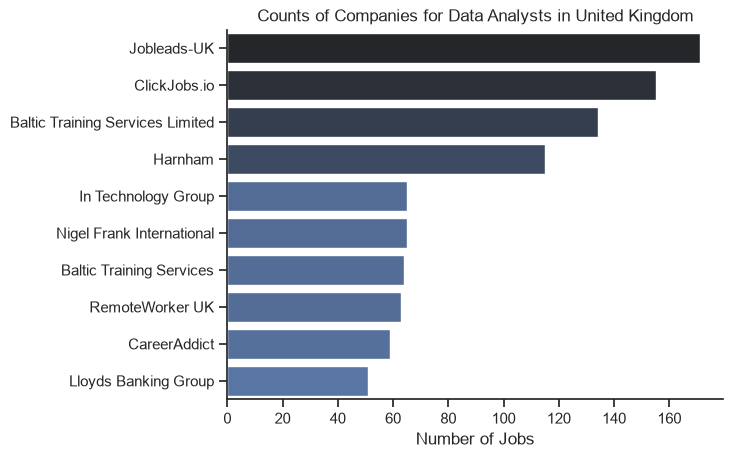

In [34]:
df_plot_2 = df_DA_UK['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style="ticks")

sns.barplot(data=df_plot_2, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title(f"Counts of Companies for {role}s in {country}")
plt.xlabel("Number of Jobs")
plt.ylabel(None)
plt.show()